In [17]:
# TÜRKİYE GENELİ KONUT FİYATI SINIFLANDIRMASI
# Sıfırdan NumPy MLP ve Elle Geri Yayılım  — v3
# Berk Burhan Cesur — 230212023

# Veri Yükleme ve Ön İşleme

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

df = pd.read_csv('/content/drive/MyDrive/emlak_verisi.csv')
print("Ham veri boyutu:", df.shape)
print("Sütunlar:", df.columns.tolist())
print("\nEksik değer sayıları:\n", df.isnull().sum())

# Düzeltme: Sütun adı 'fiyat'
PRICE_COL = "fiyat"

df = df.dropna(subset=[PRICE_COL]).reset_index(drop=True)

q33 = df[PRICE_COL].quantile(0.33)
q66 = df[PRICE_COL].quantile(0.66)
print(f"\n33. yüzdelik: {q33:,.0f} TL  |  66. yüzdelik: {q66:,.0f} TL")

df["label"] = pd.cut(
    df[PRICE_COL],
    bins=[-np.inf, q33, q66, np.inf],
    labels=[0, 1, 2]
).astype(int)

CLASS_NAMES  = ["Uygun", "Orta", "Pahalı"]
CLASS_RANGES = {
    0: f"0 - {q33:,.0f} TL",
    1: f"{q33:,.0f} - {q66:,.0f} TL",
    2: f"{q66:,.0f} TL üzeri"
}

print("Sınıf dağılımı:\n",
      df["label"].value_counts().sort_index()
      .rename({0:"Uygun", 1:"Orta", 2:"Pahalı"}))

# Ham veriyi sunum için sakla (Hücre 14'te kullanılacak)
df_raw = df.copy()

drop_cols = [PRICE_COL, "label", "Tarih"]   # Tarih Hücre 12'de ayrıca işlenecek
CAT_COLS  = [c for c in df.columns
             if df[c].dtype == "object" and c not in drop_cols + ["Tarih"]]
NUM_COLS  = [c for c in df.columns
             if df[c].dtype != "object" and c not in drop_cols]

df_enc = pd.get_dummies(df, columns=CAT_COLS, drop_first=False)
feat   = [c for c in df_enc.columns if c not in drop_cols + ["Tarih"]]

X_raw = df_enc[feat].values.astype(np.float64)
y     = df_enc["label"].values.astype(np.int32)

imputer = SimpleImputer(strategy="median")
X_raw   = imputer.fit_transform(X_raw)

X_tr_raw, X_te_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_tr_raw)
X_test  = scaler.transform(X_te_raw)

# Özellik isimlerini sakla (Hücre 13'te kullanılacak)
feature_names = feat

print(f"\nEğitim: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Özellik sayısı: {X_train.shape[1]}")
print("✓ Hücre 1 tamamlandı.")

Ham veri boyutu: (15276, 8)
Sütunlar: ['satici_tip', 'Metrekare', 'Oda_Sayisi', 'il', 'Ilce', 'Mahalle', 'Tarih', 'fiyat']

Eksik değer sayıları:
 satici_tip    0
Metrekare     0
Oda_Sayisi    0
il            0
Ilce          0
Mahalle       0
Tarih         0
fiyat         0
dtype: int64

33. yüzdelik: 2,545,000 TL  |  66. yüzdelik: 3,750,000 TL
Sınıf dağılımı:
 label
Uygun     5045
Orta      5060
Pahalı    5171
Name: count, dtype: int64

Eğitim: (12220, 563)  |  Test: (3056, 563)
Özellik sayısı: 563
✓ Hücre 1 tamamlandı.


In [18]:
# Aktivasyon Fonksiyonları ve Birim Testleri

import numpy as np

def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

def sigmoid(Z):
    pos = Z >= 0
    result = np.zeros_like(Z, dtype=float)
    result[pos]  = 1 / (1 + np.exp(-Z[pos]))
    exp_z        = np.exp(Z[~pos])
    result[~pos] = exp_z / (1 + exp_z)
    return result

def sigmoid_derivative(Z):
    s = sigmoid(Z)
    return s * (1 - s)

def softmax(Z):
    Z_s   = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(Z_s)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

# Birim Testleri
print("BİRİM TESTLERİ")
print("=" * 45)

z1 = np.array([-3., 0., 2., 5.])
assert np.array_equal(relu(z1), [0., 0., 2., 5.])
print("✓ ReLU            : negatifler sıfırlandı")

z2 = np.array([-1., 0.5, 3.])
assert np.array_equal(relu_derivative(z2), [0., 1., 1.])
print("✓ ReLU türevi     : doğru")

z3 = np.array([0., 2., -2.])
s3 = sigmoid(z3)
assert np.allclose(s3, [0.5, 0.8808, 0.1192], atol=1e-4)
print("✓ Sigmoid         : doğru →", np.round(s3, 4))

z4 = np.array([[1., 2., 3.], [0., 0., 0.]])
s4 = softmax(z4)
assert np.allclose(s4.sum(axis=1), 1.0)
print("✓ Softmax toplam  : her satır = 1")

z5 = np.array([[1000., 1001., 999.]])
assert np.all(np.isfinite(softmax(z5)))
print("✓ Softmax kararlılık: büyük girişte taşma yok")

print("\n✓ Tüm birim testleri geçti. Hücre 2 tamamlandı.")

BİRİM TESTLERİ
✓ ReLU            : negatifler sıfırlandı
✓ ReLU türevi     : doğru
✓ Sigmoid         : doğru → [0.5    0.8808 0.1192]
✓ Softmax toplam  : her satır = 1
✓ Softmax kararlılık: büyük girişte taşma yok

✓ Tüm birim testleri geçti. Hücre 2 tamamlandı.


In [19]:
# Gradient Checking

import numpy as np

def cross_entropy_loss(y_hat, y_true):
    n = y_hat.shape[0]
    Y = np.zeros_like(y_hat)
    Y[np.arange(n), y_true] = 1.
    return -np.sum(Y * np.log(y_hat + 1e-12)) / n

def _forward_check(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1;  A1 = relu(Z1)
    Z2 = A1 @ W2 + b2; A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def _analytic_grads(X, y, W1, b1, W2, b2):
    n = X.shape[0]
    Z1, A1, Z2, A2 = _forward_check(X, W1, b1, W2, b2)
    Y   = np.zeros_like(A2); Y[np.arange(n), y] = 1.
    dZ2 = (A2 - Y) / n
    dW2 = A1.T @ dZ2;  db2 = dZ2.sum(0, keepdims=True)
    dZ1 = (dZ2 @ W2.T) * relu_derivative(Z1)
    dW1 = X.T @ dZ1;   db1 = dZ1.sum(0, keepdims=True)
    return dW1, db1, dW2, db2

def _num_grad(X, y, W1, b1, W2, b2, param, eps=1e-5):
    g = np.zeros_like(param)
    it = np.nditer(param, flags=["multi_index"])
    while not it.finished:
        idx = it.multi_index; orig = param[idx]
        param[idx] = orig + eps
        lp = cross_entropy_loss(_forward_check(X,W1,b1,W2,b2)[3], y)
        param[idx] = orig - eps
        lm = cross_entropy_loss(_forward_check(X,W1,b1,W2,b2)[3], y)
        g[idx] = (lp - lm) / (2*eps); param[idx] = orig; it.iternext()
    return g

def gradient_checking():
    rng = np.random.default_rng(42)
    X_ = rng.standard_normal((8, 4))
    y_ = rng.integers(0, 3, 8)
    W1 = rng.normal(0,.1,(4,5)); b1 = np.zeros((1,5))
    W2 = rng.normal(0,.1,(5,3)); b2 = np.zeros((1,3))
    ga = _analytic_grads(X_, y_, W1, b1, W2, b2)
    print("Gradient Checking:")
    for name, g_a, param in zip(
            ["W1","b1","W2","b2"], ga, [W1,b1,W2,b2]):
        g_n  = _num_grad(X_, y_, W1, b1, W2, b2, param)
        err  = np.linalg.norm(g_a - g_n) / \
               (np.linalg.norm(g_a) + np.linalg.norm(g_n) + 1e-8)
        ok   = "✓ GEÇTI" if err < 1e-5 else "✗ HATALI"
        print(f"  {ok}  ∂{name}: göreli hata = {err:.2e}")

gradient_checking()
print("\n✓ Hücre 3 tamamlandı.")

Gradient Checking:
  ✓ GEÇTI  ∂W1: göreli hata = 2.30e-10
  ✓ GEÇTI  ∂b1: göreli hata = 1.20e-10
  ✓ GEÇTI  ∂W2: göreli hata = 2.71e-10
  ✓ GEÇTI  ∂b2: göreli hata = 2.50e-11

✓ Hücre 3 tamamlandı.


In [20]:
# CustomMLP Sınıfı

import numpy as np
import time

class CustomMLP:
    def __init__(self, layer_sizes, learning_rate=0.01, batch_size=64,
                 epochs=300, random_state=42, class_weights=None,
                 activation="relu"):
        self.layer_sizes   = layer_sizes
        self.lr            = learning_rate
        self.batch_size    = batch_size
        self.epochs        = epochs
        self.class_weights = class_weights
        self.activation    = activation
        self.rng           = np.random.default_rng(random_state)
        self.loss_history  = []
        self._init_params()

    def _act(self, Z):
        return relu(Z) if self.activation == "relu" else sigmoid(Z)

    def _act_deriv(self, Z):
        return relu_derivative(Z) if self.activation == "relu" \
               else sigmoid_derivative(Z)

    def _init_params(self):
        self.W, self.b = [], []
        for i in range(len(self.layer_sizes) - 1):
            fan_in  = self.layer_sizes[i]
            fan_out = self.layer_sizes[i + 1]
            std = (np.sqrt(2.0 / fan_in) if self.activation == "relu"
                   else np.sqrt(1.0 / fan_in))
            self.W.append(self.rng.normal(0, std, (fan_in, fan_out)))
            self.b.append(np.zeros((1, fan_out)))

    def _forward(self, X):
        self._cache = [X]
        self._Zs    = []
        A = X
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A @ W + b
            self._Zs.append(Z)
            A = self._act(Z) if i < len(self.W)-1 else softmax(Z)
            self._cache.append(A)
        return A

    def _loss(self, y_hat, y_true):
        n = y_hat.shape[0]
        Y = np.zeros_like(y_hat); Y[np.arange(n), y_true] = 1.
        if self.class_weights:
            w = np.array([self.class_weights[c] for c in y_true])
            return -np.sum(w * np.sum(Y * np.log(y_hat+1e-12), axis=1)) / n
        return -np.sum(Y * np.log(y_hat+1e-12)) / n

    def _backward(self, y_true):
        n = self._cache[0].shape[0]
        Y = np.zeros_like(self._cache[-1]); Y[np.arange(n), y_true] = 1.
        dZ = (self._cache[-1] - Y) / n
        if self.class_weights:
            w  = np.array([self.class_weights[c] for c in y_true]).reshape(-1,1)
            dZ = w * dZ
        self.dW = [None]*len(self.W); self.db = [None]*len(self.W)
        for i in reversed(range(len(self.W))):
            A_prev = self._cache[i]
            assert A_prev.shape[1] == self.W[i].shape[0], \
                f"Boyut hatası katman {i}"
            self.dW[i] = A_prev.T @ dZ
            self.db[i] = dZ.sum(0, keepdims=True)
            if i > 0:
                dZ = (dZ @ self.W[i].T) * self._act_deriv(self._Zs[i-1])

    def _update(self):
        for i in range(len(self.W)):
            self.W[i] -= self.lr * self.dW[i]
            self.b[i]  -= self.lr * self.db[i]

    def fit(self, X, y, verbose=True):
        n = X.shape[0]; self.loss_history = []
        for ep in range(1, self.epochs+1):
            idx = self.rng.permutation(n)
            Xs, ys = X[idx], y[idx]
            ep_loss, nb = 0., 0
            for s in range(0, n, self.batch_size):
                Xb, yb = Xs[s:s+self.batch_size], ys[s:s+self.batch_size]
                yh = self._forward(Xb)
                ep_loss += self._loss(yh, yb); nb += 1
                self._backward(yb); self._update()
            self.loss_history.append(ep_loss / nb)
            if verbose and (ep % 50 == 0 or ep == 1):
                print(f"  Epoch {ep:>4}/{self.epochs}  Loss: {ep_loss/nb:.5f}")
        return self

    def predict_proba(self, X): return self._forward(X)
    def predict(self, X):       return np.argmax(self.predict_proba(X), axis=1)
    def score(self, X, y):      return np.mean(self.predict(X) == y)

print("CustomMLP sınıfı hazır.")
print("✓ Hücre 4 tamamlandı.")

CustomMLP sınıfı hazır.
✓ Hücre 4 tamamlandı.


[Overfitting Testi] 500 epoch …

  Epoch    1/500  Loss: 1.02269
  Epoch   50/500  Loss: 0.03337
  Epoch  100/500  Loss: 0.01120
  Epoch  150/500  Loss: 0.00601
  Epoch  200/500  Loss: 0.00392
  Epoch  250/500  Loss: 0.00285
  Epoch  300/500  Loss: 0.00220
  Epoch  350/500  Loss: 0.00178
  Epoch  400/500  Loss: 0.00148
  Epoch  450/500  Loss: 0.00127
  Epoch  500/500  Loss: 0.00110

Son Loss : 0.001100
Eğitim Acc (10 örnek): 1.0000
✓ Loss ≈ 0  →  Geri yayılım matematiği doğru.


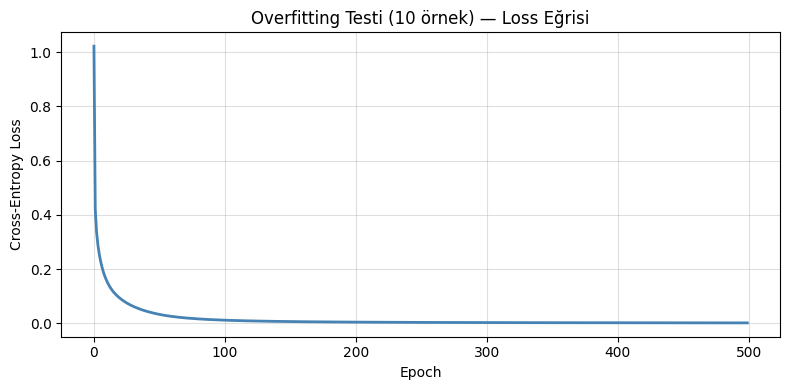

✓ Hücre 5 tamamlandı.


In [21]:
# Overfitting Testi (10 Örnek)

import matplotlib.pyplot as plt

X_tiny = X_train[:10]; y_tiny = y_train[:10]
mlp_tiny = CustomMLP(
    layer_sizes=[X_train.shape[1], 64, 32, 3],
    learning_rate=0.05, batch_size=10, epochs=500, random_state=42)

print("[Overfitting Testi] 500 epoch …\n")
mlp_tiny.fit(X_tiny, y_tiny, verbose=True)

print(f"\nSon Loss : {mlp_tiny.loss_history[-1]:.6f}")
print(f"Eğitim Acc (10 örnek): {mlp_tiny.score(X_tiny, y_tiny):.4f}")
print("✓ Loss ≈ 0  →  Geri yayılım matematiği doğru." if
      mlp_tiny.loss_history[-1] < 0.05 else
      "⚠ Loss hâlâ yüksek.")

plt.figure(figsize=(8,4))
plt.plot(mlp_tiny.loss_history, color="steelblue", lw=2)
plt.xlabel("Epoch"); plt.ylabel("Cross-Entropy Loss")
plt.title("Overfitting Testi (10 örnek) — Loss Eğrisi"); plt.grid(alpha=.4)
plt.tight_layout(); plt.savefig("overfitting_test.png", dpi=150); plt.show()
print("✓ Hücre 5 tamamlandı.")

In [22]:
# Baseline Modeller

from sklearn.neural_network import MLPClassifier
from sklearn.linear_model   import LogisticRegression

sklearn_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32), activation="relu", solver="sgd",
    learning_rate_init=0.01, batch_size=64, max_iter=300,
    random_state=42, verbose=False)

logreg_baseline = LogisticRegression(
    max_iter=1000, random_state=42,
    multi_class="multinomial", solver="lbfgs")

print("Baseline modeller tanımlandı.")
print("✓ Hücre 6 tamamlandı.")

Baseline modeller tanımlandı.
✓ Hücre 6 tamamlandı.


Sınıf ağırlıkları: {'Uygun': np.float64(1.009), 'Orta': np.float64(1.006), 'Pahalı': np.float64(0.985)}

[Model 1] CustomMLP eğitiliyor …
  Epoch    1/300  Loss: 1.09310
  Epoch   50/300  Loss: 0.61260
  Epoch  100/300  Loss: 0.59056
  Epoch  150/300  Loss: 0.57470
  Epoch  200/300  Loss: 0.56250
  Epoch  250/300  Loss: 0.55253
  Epoch  300/300  Loss: 0.54447

  Süre:74.9s  Acc:0.6849  Macro-F1:0.6866  LogLoss:0.8450
              precision    recall  f1-score   support

       Uygun       0.75      0.66      0.71      1009
        Orta       0.56      0.63      0.60      1012
      Pahalı       0.76      0.76      0.76      1035

    accuracy                           0.68      3056
   macro avg       0.69      0.68      0.69      3056
weighted avg       0.69      0.68      0.69      3056

[Model 2] sklearn MLP eğitiliyor …


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



  Süre:106.7s  Acc:0.6682  Macro-F1:0.6718  LogLoss:0.9685
              precision    recall  f1-score   support

       Uygun       0.75      0.64      0.69      1009
        Orta       0.54      0.67      0.60      1012
      Pahalı       0.76      0.70      0.73      1035

    accuracy                           0.67      3056
   macro avg       0.68      0.67      0.67      3056
weighted avg       0.68      0.67      0.67      3056

[Model 3] Lojistik Regresyon eğitiliyor …

  Süre:3.3s  Acc:0.6813  Macro-F1:0.6836  LogLoss:0.7812
              precision    recall  f1-score   support

       Uygun       0.75      0.69      0.72      1009
        Orta       0.56      0.62      0.59      1012
      Pahalı       0.76      0.73      0.75      1035

    accuracy                           0.68      3056
   macro avg       0.69      0.68      0.68      3056
weighted avg       0.69      0.68      0.68      3056


Model                         Macro-F1  Accuracy   LogLoss   Süre(s)
--------

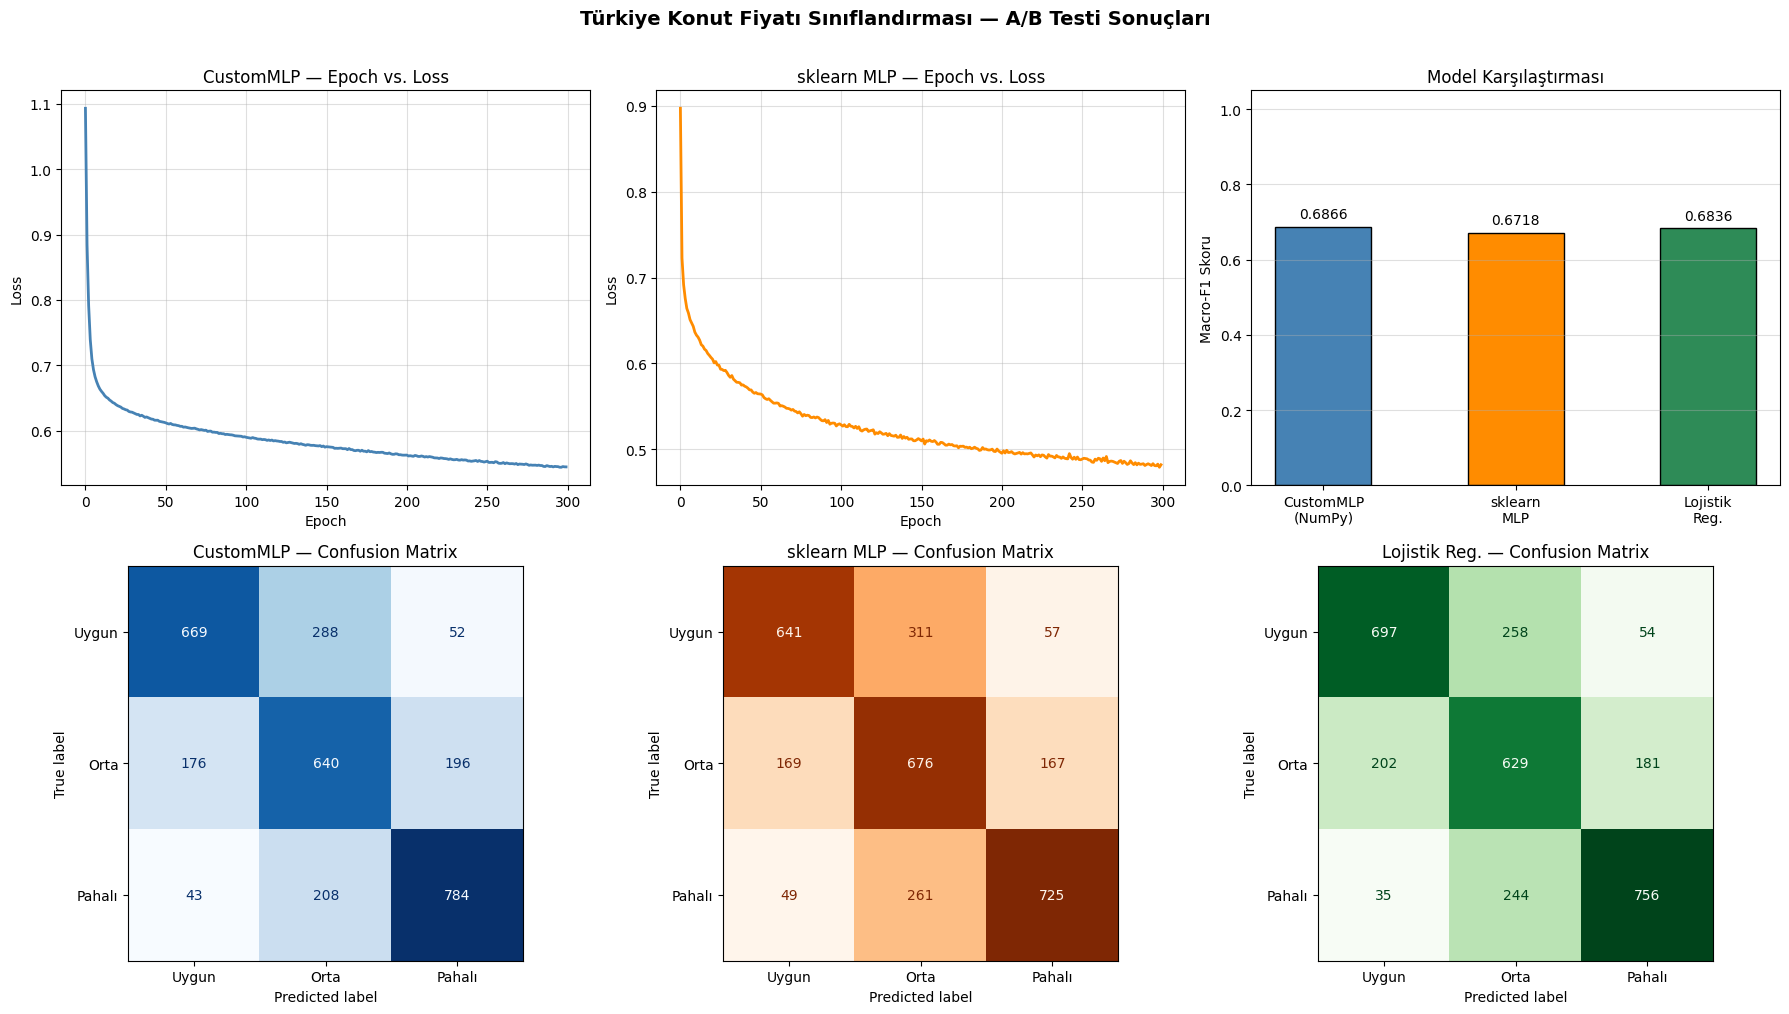

✓ Hücre 7 tamamlandı.


In [23]:
# Asıl Eğitim ve Karşılaştırma (A/B Testi)

import time, numpy as np, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (f1_score, accuracy_score, log_loss,
                              confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
cw_arr  = compute_class_weight("balanced", classes=classes, y=y_train)
cw_dict = dict(zip(classes, cw_arr))
print("Sınıf ağırlıkları:", {CLASS_NAMES[k]: round(v,3) for k,v in cw_dict.items()})

# CustomMLP
print("\n[Model 1] CustomMLP eğitiliyor …")
custom_mlp = CustomMLP(
    layer_sizes=[X_train.shape[1], 64, 32, 3],
    learning_rate=0.01, batch_size=64, epochs=300,
    random_state=42, class_weights=cw_dict, activation="relu")
t0 = time.time(); custom_mlp.fit(X_train, y_train, verbose=True)
t_custom = time.time() - t0

yp_c  = custom_mlp.predict(X_test)
ypr_c = custom_mlp.predict_proba(X_test)
acc_c = accuracy_score(y_test, yp_c)
f1_c  = f1_score(y_test, yp_c, average="macro")
ll_c  = log_loss(y_test, ypr_c)
print(f"\n  Süre:{t_custom:.1f}s  Acc:{acc_c:.4f}  Macro-F1:{f1_c:.4f}  LogLoss:{ll_c:.4f}")
print(classification_report(y_test, yp_c, target_names=CLASS_NAMES))

# sklearn MLP
print("[Model 2] sklearn MLP eğitiliyor …")
t0 = time.time(); sklearn_mlp.fit(X_train, y_train)
t_sk = time.time() - t0

yp_sk  = sklearn_mlp.predict(X_test)
ypr_sk = sklearn_mlp.predict_proba(X_test)
acc_sk = accuracy_score(y_test, yp_sk)
f1_sk  = f1_score(y_test, yp_sk, average="macro")
ll_sk  = log_loss(y_test, ypr_sk)
print(f"\n  Süre:{t_sk:.1f}s  Acc:{acc_sk:.4f}  Macro-F1:{f1_sk:.4f}  LogLoss:{ll_sk:.4f}")
print(classification_report(y_test, yp_sk, target_names=CLASS_NAMES))

# Lojistik Regresyon
print("[Model 3] Lojistik Regresyon eğitiliyor …")
t0 = time.time(); logreg_baseline.fit(X_train, y_train)
t_lr = time.time() - t0

yp_lr  = logreg_baseline.predict(X_test)
ypr_lr = logreg_baseline.predict_proba(X_test)
acc_lr = accuracy_score(y_test, yp_lr)
f1_lr  = f1_score(y_test, yp_lr, average="macro")
ll_lr  = log_loss(y_test, ypr_lr)
print(f"\n  Süre:{t_lr:.1f}s  Acc:{acc_lr:.4f}  Macro-F1:{f1_lr:.4f}  LogLoss:{ll_lr:.4f}")
print(classification_report(y_test, yp_lr, target_names=CLASS_NAMES))

# Özet tablo
print("\n" + "="*65)
print(f"{'Model':<28}{'Macro-F1':>10}{'Accuracy':>10}{'LogLoss':>10}{'Süre(s)':>10}")
print("-"*65)
for nm,f1,ac,ll,t in [
    ("CustomMLP (NumPy)",     f1_c,  acc_c,  ll_c,  t_custom),
    ("sklearn MLPClassifier", f1_sk, acc_sk, ll_sk, t_sk),
    ("Lojistik Regresyon",    f1_lr, acc_lr, ll_lr, t_lr)]:
    print(f"{nm:<28}{f1:>10.4f}{ac:>10.4f}{ll:>10.4f}{t:>10.2f}")
print("="*65)

# Grafik
fig = plt.figure(figsize=(18,10))
gs  = gridspec.GridSpec(2,3,figure=fig)

for ax, hist, title, color in [
    (fig.add_subplot(gs[0,0]), custom_mlp.loss_history,  "CustomMLP — Epoch vs. Loss",   "steelblue"),
    (fig.add_subplot(gs[0,1]), sklearn_mlp.loss_curve_,  "sklearn MLP — Epoch vs. Loss", "darkorange")]:
    ax.plot(hist, color=color, lw=2); ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss"); ax.set_title(title); ax.grid(alpha=.4)

ax3 = fig.add_subplot(gs[0,2])
bars = ax3.bar(["CustomMLP\n(NumPy)","sklearn\nMLP","Lojistik\nReg."],
               [f1_c, f1_sk, f1_lr],
               color=["steelblue","darkorange","seagreen"], edgecolor="black", width=.5)
ax3.set_ylim(0,1.05); ax3.set_ylabel("Macro-F1 Skoru")
ax3.set_title("Model Karşılaştırması"); ax3.grid(axis="y",alpha=.4)
ax3.bar_label(bars, labels=[f"{v:.4f}" for v in [f1_c,f1_sk,f1_lr]], padding=4)

for ax, yp, title, cmap in [
    (fig.add_subplot(gs[1,0]), yp_c,  "CustomMLP — Confusion Matrix",     "Blues"),
    (fig.add_subplot(gs[1,1]), yp_sk, "sklearn MLP — Confusion Matrix",   "Oranges"),
    (fig.add_subplot(gs[1,2]), yp_lr, "Lojistik Reg. — Confusion Matrix", "Greens")]:
    ConfusionMatrixDisplay(confusion_matrix(y_test,yp),
                           display_labels=CLASS_NAMES).plot(ax=ax,colorbar=False,cmap=cmap)
    ax.set_title(title)

plt.suptitle("Türkiye Konut Fiyatı Sınıflandırması — A/B Testi Sonuçları",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("ab_test_sonuclari_v3.png", dpi=150, bbox_inches="tight"); plt.show()
print("✓ Hücre 7 tamamlandı.")

DENEY 1: ReLU vs Sigmoid

[RELU] eğitim başlıyor …
  Süre:72.2s  Macro-F1:0.6866  Son Loss:0.54447

[SIGMOID] eğitim başlıyor …
  Süre:133.1s  Macro-F1:0.6969  Son Loss:0.63243


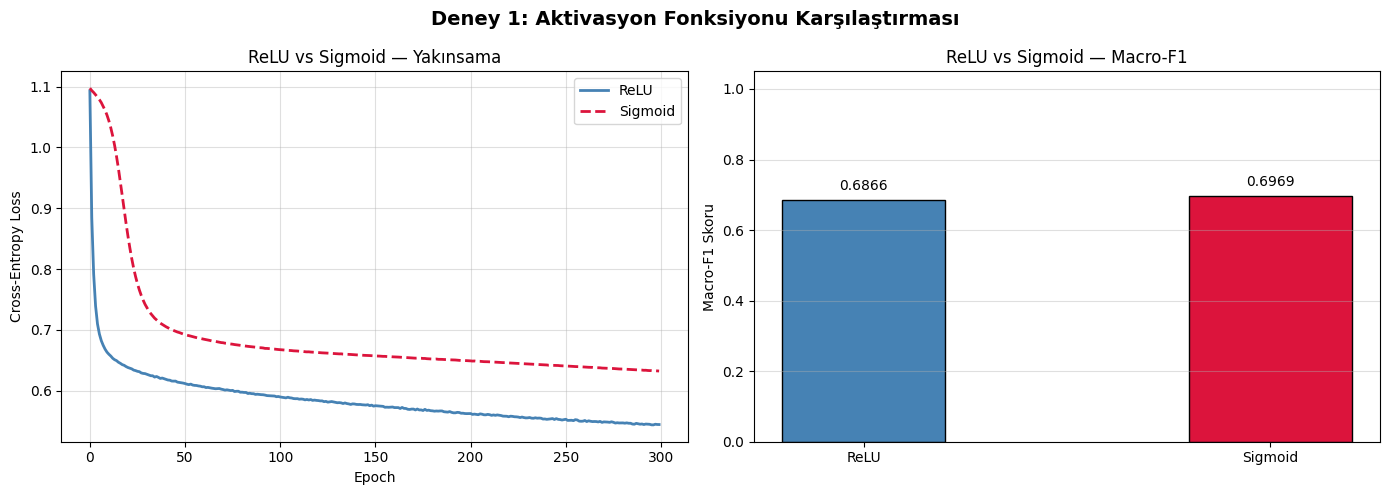


ReLU - Sigmoid farkı: -0.0103
✓ Hücre 8 tamamlandı.


In [24]:
# ReLU vs Sigmoid Aktivasyon Karşılaştırması

import time, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import f1_score

print("=" * 55)
print("DENEY 1: ReLU vs Sigmoid")
print("=" * 55)

results_act = {}
for act in ["relu", "sigmoid"]:
    print(f"\n[{act.upper()}] eğitim başlıyor …")
    model = CustomMLP(
        layer_sizes=[X_train.shape[1], 64, 32, 3],
        learning_rate=0.01, batch_size=64, epochs=300,
        random_state=42, class_weights=cw_dict, activation=act)
    t0 = time.time(); model.fit(X_train, y_train, verbose=False)
    sure = time.time() - t0
    yp = model.predict(X_test)
    f1 = f1_score(y_test, yp, average="macro")
    results_act[act] = {"model": model, "f1": f1, "sure": sure}
    print(f"  Süre:{sure:.1f}s  Macro-F1:{f1:.4f}  Son Loss:{model.loss_history[-1]:.5f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(results_act["relu"]["model"].loss_history,
        color="steelblue", lw=2, label="ReLU")
ax.plot(results_act["sigmoid"]["model"].loss_history,
        color="crimson", lw=2, linestyle="--", label="Sigmoid")
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("ReLU vs Sigmoid — Yakınsama"); ax.legend(); ax.grid(alpha=.4)

ax2 = axes[1]
f1s = [results_act["relu"]["f1"], results_act["sigmoid"]["f1"]]
bars = ax2.bar(["ReLU","Sigmoid"], f1s,
               color=["steelblue","crimson"], edgecolor="black", width=.4)
ax2.set_ylim(0,1.05); ax2.set_ylabel("Macro-F1 Skoru")
ax2.set_title("ReLU vs Sigmoid — Macro-F1")
ax2.bar_label(bars, labels=[f"{v:.4f}" for v in f1s], padding=5)
ax2.grid(axis="y",alpha=.4)

plt.suptitle("Deney 1: Aktivasyon Fonksiyonu Karşılaştırması",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("relu_vs_sigmoid.png", dpi=150, bbox_inches="tight"); plt.show()

fark = results_act["relu"]["f1"] - results_act["sigmoid"]["f1"]
print(f"\nReLU - Sigmoid farkı: {fark:+.4f}")
print("✓ Hücre 8 tamamlandı.")

DENEY 2: 1 Katman vs 2 Katman

[1 Gizli Katman (64→3)] Mimari: [563, 64, 3]
  Süre:65.4s  Macro-F1:0.6926  Son Loss:0.57651

[2 Gizli Katman (64→32→3)] Mimari: [563, 64, 32, 3]
  Süre:69.1s  Macro-F1:0.6866  Son Loss:0.54447


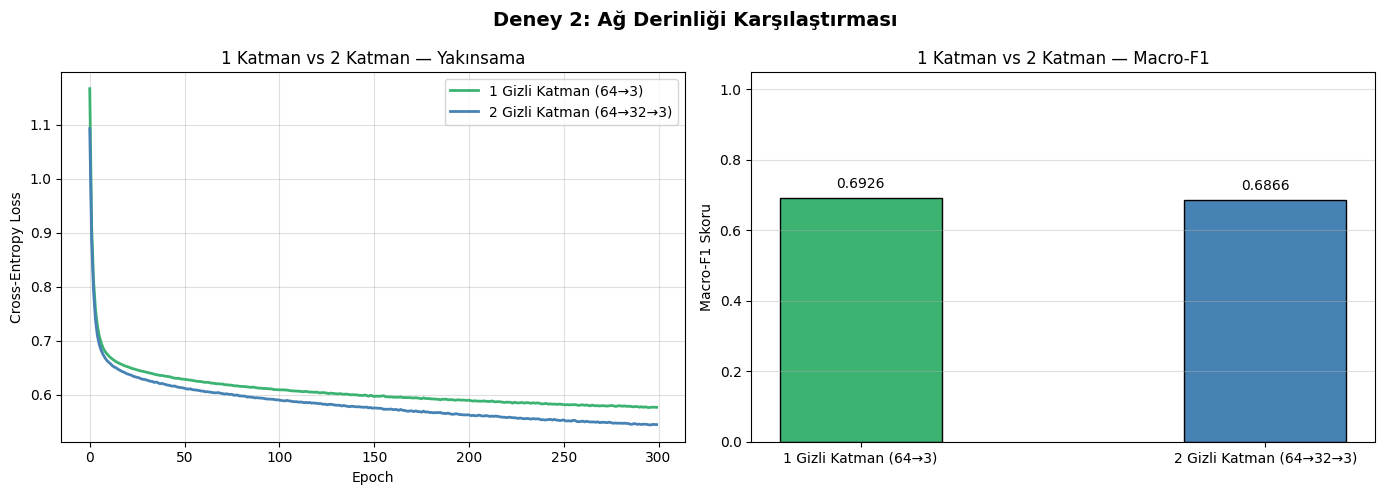


2 katman - 1 katman farkı: -0.0060
✓ Hücre 9 tamamlandı.


In [25]:
# 1 Gizli Katman vs 2 Gizli Katman
# Mimari A: 64→3  (1 gizli katman)
# Mimari B: 64→32→3  (2 gizli katman)

import time, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import f1_score

print("=" * 55)
print("DENEY 2: 1 Katman vs 2 Katman")
print("=" * 55)

architectures = {
    "1 Gizli Katman\n(64→3)":    [X_train.shape[1], 64, 3],
    "2 Gizli Katman\n(64→32→3)": [X_train.shape[1], 64, 32, 3],
}
results_depth = {}
colors_depth  = ["mediumseagreen", "steelblue"]

for label, layers in architectures.items():
    print(f"\n[{label.replace(chr(10),' ')}] Mimari: {layers}")
    model = CustomMLP(layer_sizes=layers, learning_rate=0.01,
                      batch_size=64, epochs=300, random_state=42,
                      class_weights=cw_dict, activation="relu")
    t0 = time.time(); model.fit(X_train, y_train, verbose=False)
    sure = time.time() - t0
    yp = model.predict(X_test)
    f1 = f1_score(y_test, yp, average="macro")
    results_depth[label] = {"model": model, "f1": f1, "sure": sure}
    print(f"  Süre:{sure:.1f}s  Macro-F1:{f1:.4f}  Son Loss:{model.loss_history[-1]:.5f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for (label, res), color in zip(results_depth.items(), colors_depth):
    ax.plot(res["model"].loss_history, color=color, lw=2,
            label=label.replace("\n"," "))
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("1 Katman vs 2 Katman — Yakınsama")
ax.legend(); ax.grid(alpha=.4)

ax2 = axes[1]
labels_c = [l.replace("\n"," ") for l in results_depth]
f1s = [results_depth[l]["f1"] for l in results_depth]
bars = ax2.bar(labels_c, f1s, color=colors_depth, edgecolor="black", width=.4)
ax2.set_ylim(0,1.05); ax2.set_ylabel("Macro-F1 Skoru")
ax2.set_title("1 Katman vs 2 Katman — Macro-F1")
ax2.bar_label(bars, labels=[f"{v:.4f}" for v in f1s], padding=5)
ax2.grid(axis="y",alpha=.4)

plt.suptitle("Deney 2: Ağ Derinliği Karşılaştırması",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("derinlik_karsilastirma.png", dpi=150, bbox_inches="tight"); plt.show()

f1_vals = list(results_depth.values())
print(f"\n2 katman - 1 katman farkı: {f1_vals[1]['f1'] - f1_vals[0]['f1']:+.4f}")
print("✓ Hücre 9 tamamlandı.")

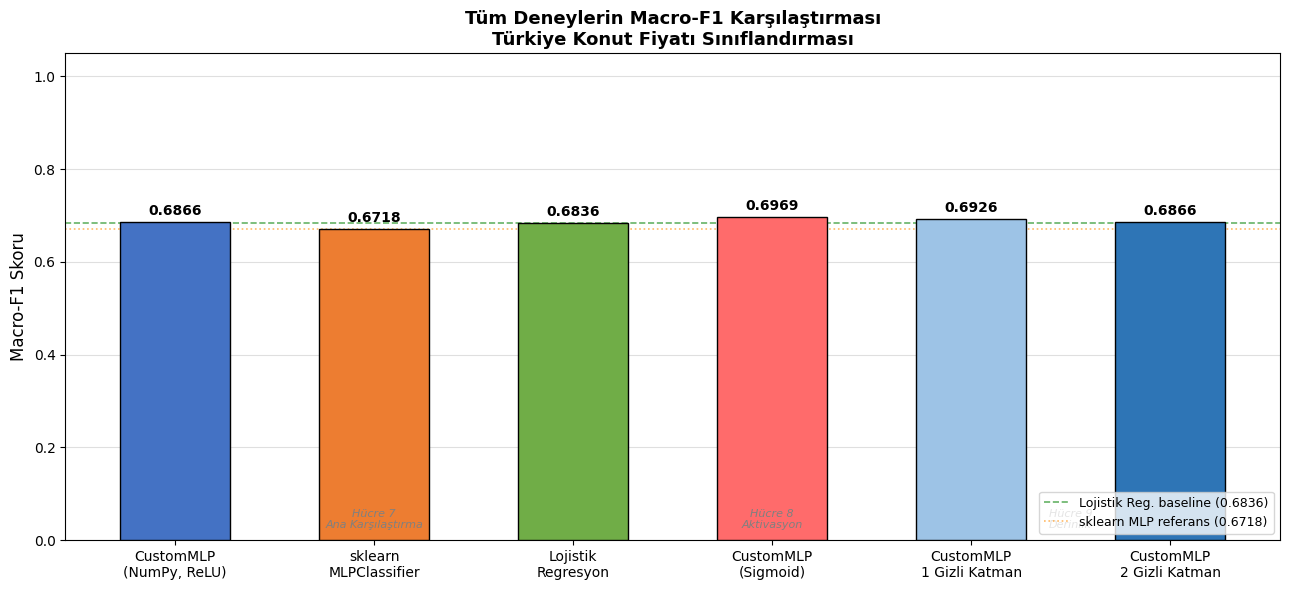

✓ Hücre 10 tamamlandı.


In [26]:
# Tüm Deneylerin Özet Grafiği

import matplotlib.pyplot as plt
import numpy as np

model_names = [
    "CustomMLP\n(NumPy, ReLU)", "sklearn\nMLPClassifier", "Lojistik\nRegresyon",
    "CustomMLP\n(Sigmoid)",
    "CustomMLP\n1 Gizli Katman", "CustomMLP\n2 Gizli Katman",
]
f1_scores_all = [
    f1_c, f1_sk, f1_lr,
    results_act["sigmoid"]["f1"],
    list(results_depth.values())[0]["f1"],
    list(results_depth.values())[1]["f1"],
]
group_colors = ["#4472C4","#ED7D31","#70AD47","#FF6B6B","#9DC3E6","#2E75B6"]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(model_names, f1_scores_all, color=group_colors,
              edgecolor="black", width=0.55, zorder=3)
for bar, val in zip(bars, f1_scores_all):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.axhline(f1_lr, color="green", linestyle="--", lw=1.2, alpha=.6,
           label=f"Lojistik Reg. baseline ({f1_lr:.4f})")
ax.axhline(f1_sk, color="darkorange", linestyle=":", lw=1.2, alpha=.6,
           label=f"sklearn MLP referans ({f1_sk:.4f})")
ax.set_ylim(0,1.05); ax.set_ylabel("Macro-F1 Skoru", fontsize=12)
ax.set_title("Tüm Deneylerin Macro-F1 Karşılaştırması\nTürkiye Konut Fiyatı Sınıflandırması",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right"); ax.grid(axis="y", alpha=.4, zorder=0)

for x, txt in [(1.0,"Hücre 7\nAna Karşılaştırma"),
               (3.0,"Hücre 8\nAktivasyon"),
               (4.5,"Hücre 9\nDerinlik")]:
    ax.text(x, 0.02, txt, ha="center", va="bottom", fontsize=8,
            color="gray", style="italic", transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.savefig("ozet_grafik.png", dpi=150, bbox_inches="tight"); plt.show()
print("✓ Hücre 10 tamamlandı.")

Keşifsel Veri Analizi başlıyor …


/tmp/ipykernel_663/829047772.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(veri_gruplari, labels=satici_tipler,


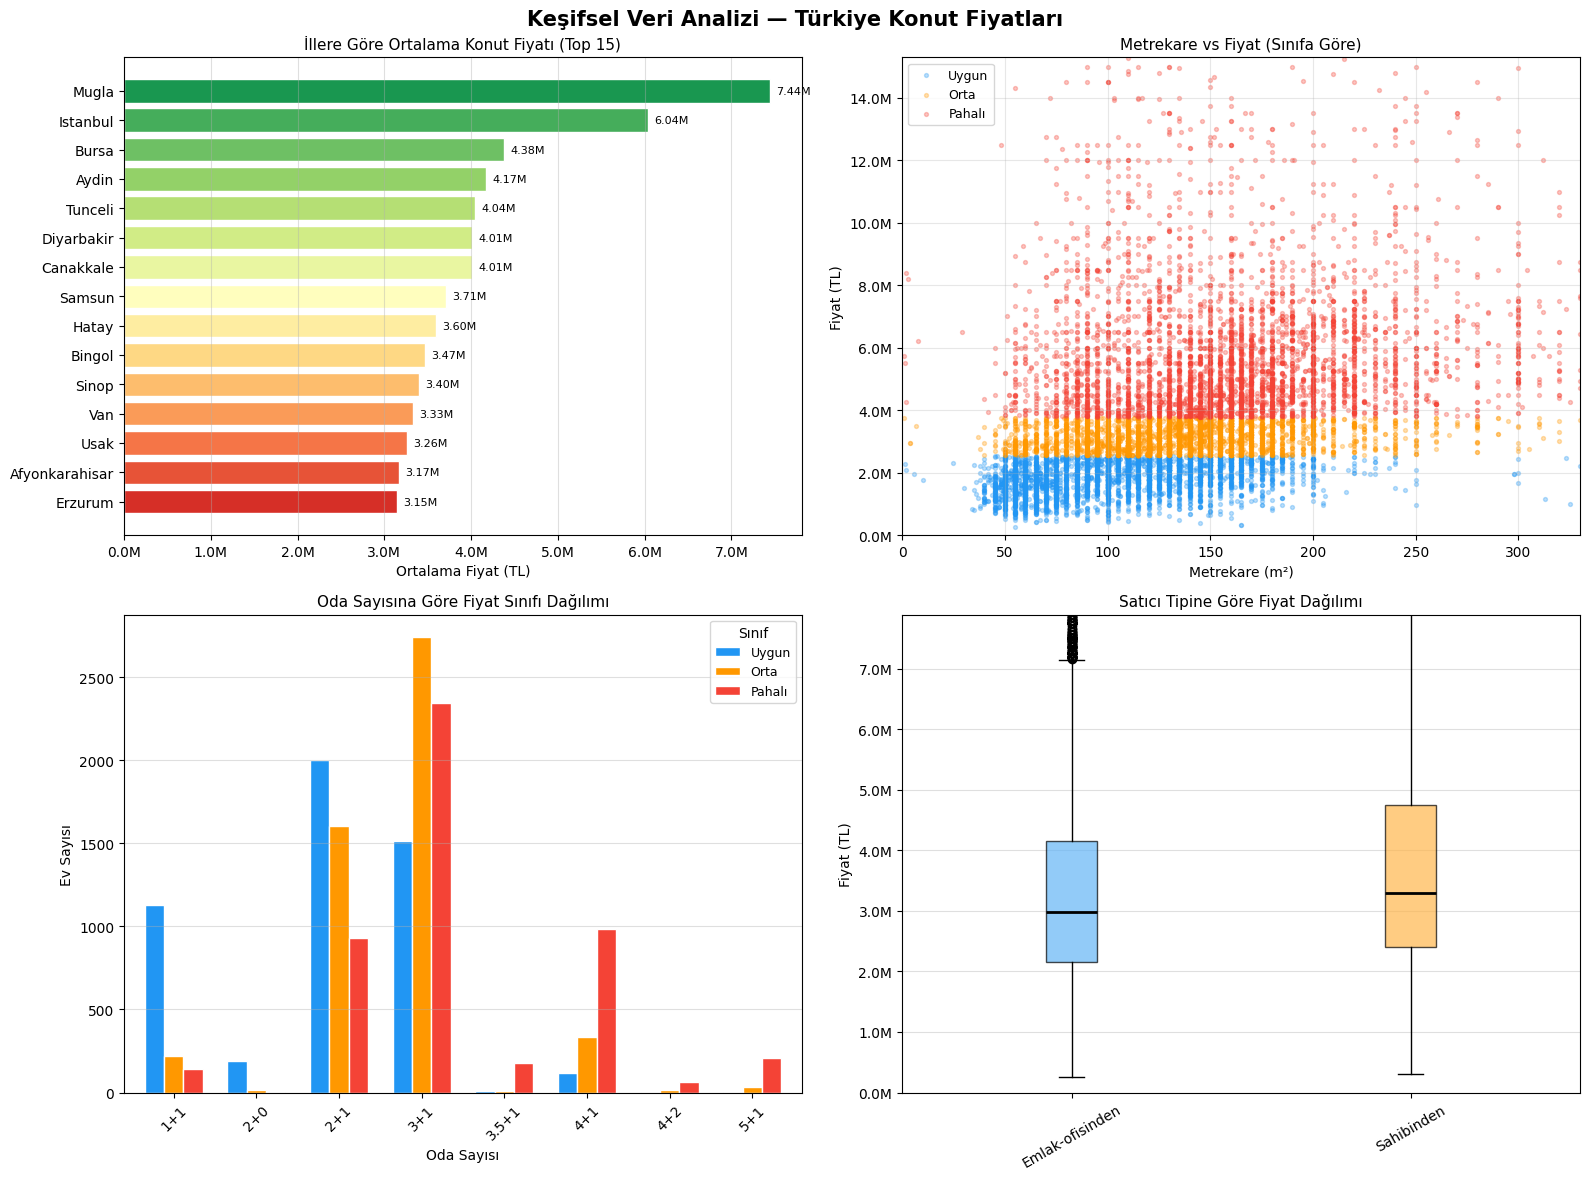


── Temel İstatistikler ──────────────────────────────────
  Toplam ilan sayısı : 15,276
  Ortalama fiyat     : 3,790,934 TL
  Medyan fiyat       : 3,100,000 TL
  En pahalı il       : Mugla
  Ortalama metrekare : 135.9 m²
  Satıcı tipleri     : {'Emlak-ofisinden': 9160, 'Sahibinden': 6116}

✓ Hücre 11 tamamlandı.


In [27]:
# Keşifsel Veri Analizi (EDA)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print("Keşifsel Veri Analizi başlıyor …")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Keşifsel Veri Analizi — Türkiye Konut Fiyatları",
             fontsize=15, fontweight="bold")

sinif_renk = {0: "#2196F3", 1: "#FF9800", 2: "#F44336"}
sinif_ad   = {0: "Uygun", 1: "Orta", 2: "Pahalı"}

# 1. İllere göre ortalama fiyat (Top 15)
ax1 = axes[0, 0]
il_ort = (df_raw.groupby("il")[PRICE_COL].mean()
          .sort_values(ascending=False).head(15))
renkler = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(il_ort)))
bars = ax1.barh(il_ort.index[::-1], il_ort.values[::-1],
                color=renkler[::-1], edgecolor="white")
ax1.set_xlabel("Ortalama Fiyat (TL)", fontsize=10)
ax1.set_title("İllere Göre Ortalama Konut Fiyatı (Top 15)", fontsize=11)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e6:.1f}M"))
ax1.grid(axis="x", alpha=.4)
for bar, val in zip(bars, il_ort.values[::-1]):
    ax1.text(val + il_ort.max()*0.01, bar.get_y()+bar.get_height()/2,
             f"{val/1e6:.2f}M", va="center", fontsize=8)

# 2. Metrekare vs Fiyat (sınıfa göre renkli)
ax2 = axes[0, 1]
for sinif, renk in sinif_renk.items():
    alt = df_raw[df_raw["label"] == sinif]
    ax2.scatter(alt["Metrekare"], alt[PRICE_COL],
                c=renk, alpha=0.3, s=8, label=sinif_ad[sinif])
ax2.set_xlabel("Metrekare (m²)", fontsize=10)
ax2.set_ylabel("Fiyat (TL)", fontsize=10)
ax2.set_title("Metrekare vs Fiyat (Sınıfa Göre)", fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e6:.1f}M"))
ax2.legend(fontsize=9); ax2.grid(alpha=.3)
# Metrekare sınırla (aykırı değerleri gizle)
ax2.set_xlim(0, df_raw["Metrekare"].quantile(0.99))
ax2.set_ylim(0, df_raw[PRICE_COL].quantile(0.99))

# 3. Oda Sayısına Göre Sınıf Dağılımı
ax3 = axes[1, 0]
oda_sinif = (df_raw.groupby(["Oda_Sayisi", "label"])
             .size().unstack(fill_value=0))
# En yaygın 8 oda tipini al
top_oda = df_raw["Oda_Sayisi"].value_counts().head(8).index
oda_sinif = oda_sinif.loc[oda_sinif.index.isin(top_oda)]
oda_sinif.columns = [sinif_ad[c] for c in oda_sinif.columns]
oda_sinif.plot(kind="bar", ax=ax3, color=["#2196F3","#FF9800","#F44336"],
               edgecolor="white", width=0.7)
ax3.set_xlabel("Oda Sayısı", fontsize=10)
ax3.set_ylabel("Ev Sayısı", fontsize=10)
ax3.set_title("Oda Sayısına Göre Fiyat Sınıfı Dağılımı", fontsize=11)
ax3.legend(title="Sınıf", fontsize=9); ax3.grid(axis="y", alpha=.4)
ax3.tick_params(axis="x", rotation=45)

# 4. Satıcı Tipine Göre Fiyat Dağılımı
ax4 = axes[1, 1]
satici_tipler = df_raw["satici_tip"].value_counts().index.tolist()
veri_gruplari = [df_raw[df_raw["satici_tip"]==s][PRICE_COL].values
                 for s in satici_tipler]
bp = ax4.boxplot(veri_gruplari, labels=satici_tipler,
                 patch_artist=True, notch=False,
                 medianprops=dict(color="black", lw=2))
renkler_bp = ["#64B5F6","#FFB74D","#81C784","#E57373"]
for patch, renk in zip(bp["boxes"], renkler_bp[:len(satici_tipler)]):
    patch.set_facecolor(renk); patch.set_alpha(0.7)
ax4.set_ylabel("Fiyat (TL)", fontsize=10)
ax4.set_title("Satıcı Tipine Göre Fiyat Dağılımı", fontsize=11)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e6:.1f}M"))
ax4.set_ylim(0, df_raw[PRICE_COL].quantile(0.95))
ax4.grid(axis="y", alpha=.4)
ax4.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("eda_analiz.png", dpi=150, bbox_inches="tight"); plt.show()

# Özet istatistikler
print("\n── Temel İstatistikler ──────────────────────────────────")
print(f"  Toplam ilan sayısı : {len(df_raw):,}")
print(f"  Ortalama fiyat     : {df_raw[PRICE_COL].mean():,.0f} TL")
print(f"  Medyan fiyat       : {df_raw[PRICE_COL].median():,.0f} TL")
print(f"  En pahalı il       : {df_raw.groupby('il')[PRICE_COL].mean().idxmax()}")
print(f"  Ortalama metrekare : {df_raw['Metrekare'].mean():.1f} m²")
print(f"  Satıcı tipleri     : {df_raw['satici_tip'].value_counts().to_dict()}")
print("\n✓ Hücre 11 tamamlandı.")

Tarih Analizi başlıyor …
  Tarih aralığı: NaT → NaT
  Toplam ilan  : 0


/tmp/ipykernel_663/1562280796.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_t["Tarih"] = pd.to_datetime(df_t["Tarih"], errors="coerce")
/tmp/ipykernel_663/1562280796.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(fontsize=9); ax3.grid(alpha=.4)


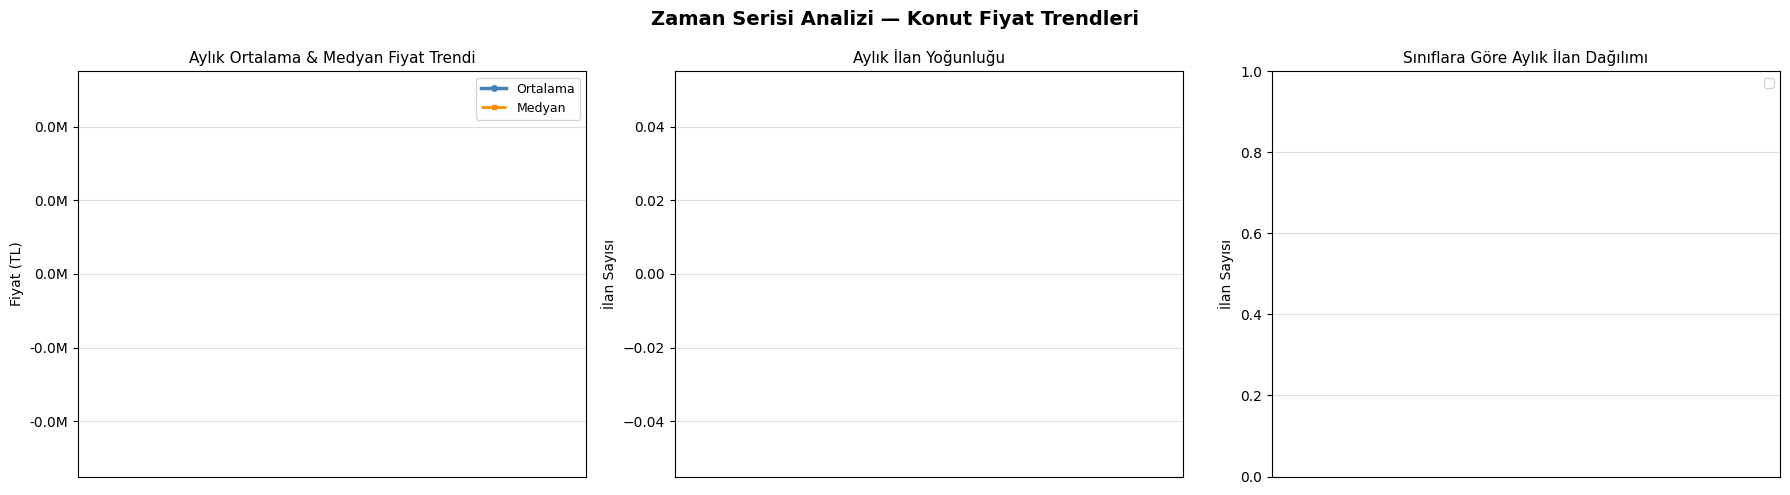

✓ Hücre 12 tamamlandı.


In [28]:
# Tarih Analizi

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print("Tarih Analizi başlıyor …")

# Tarih sütununu parse et
df_t = df_raw.copy()
df_t["Tarih"] = pd.to_datetime(df_t["Tarih"], errors="coerce")
df_t = df_t.dropna(subset=["Tarih"])
df_t["Yil_Ay"] = df_t["Tarih"].dt.to_period("M")
df_t["Ay"]     = df_t["Tarih"].dt.month
df_t["Yil"]    = df_t["Tarih"].dt.year

print(f"  Tarih aralığı: {df_t['Tarih'].min().date()} → {df_t['Tarih'].max().date()}")
print(f"  Toplam ilan  : {len(df_t):,}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Zaman Serisi Analizi — Konut Fiyat Trendleri",
             fontsize=14, fontweight="bold")

# 1. Aylık Ortalama Fiyat Trendi
ax1 = axes[0]
aylik_ort = df_t.groupby("Yil_Ay")[PRICE_COL].mean()
aylik_med = df_t.groupby("Yil_Ay")[PRICE_COL].median()
x_vals = range(len(aylik_ort))
ax1.plot(x_vals, aylik_ort.values, color="steelblue",
         lw=2.5, label="Ortalama", marker="o", markersize=4)
ax1.plot(x_vals, aylik_med.values, color="darkorange",
         lw=2, linestyle="--", label="Medyan", marker="s", markersize=3)
ax1.set_xticks(x_vals[::max(1, len(x_vals)//8)])
ax1.set_xticklabels([str(aylik_ort.index[i]) for i in x_vals[::max(1,len(x_vals)//8)]],
                    rotation=45, ha="right", fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
ax1.set_ylabel("Fiyat (TL)", fontsize=10)
ax1.set_title("Aylık Ortalama & Medyan Fiyat Trendi", fontsize=11)
ax1.legend(fontsize=9); ax1.grid(alpha=.4)

# 2. Aylara Göre İlan Yoğunluğu
ax2 = axes[1]
ay_sayisi = df_t.groupby("Yil_Ay").size()
x2 = range(len(ay_sayisi))
ax2.bar(x2, ay_sayisi.values, color="mediumpurple", edgecolor="white", alpha=0.8)
ax2.set_xticks(list(x2)[::max(1, len(x2)//8)])
ax2.set_xticklabels([str(ay_sayisi.index[i]) for i in list(x2)[::max(1,len(x2)//8)]],
                    rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("İlan Sayısı", fontsize=10)
ax2.set_title("Aylık İlan Yoğunluğu", fontsize=11)
ax2.grid(axis="y", alpha=.4)

# 3. Sınıfların Aylık Dağılımı
ax3 = axes[2]
sinif_trend = (df_t.groupby(["Yil_Ay","label"])
               .size().unstack(fill_value=0))
sinif_trend.columns = [sinif_ad[c] for c in sinif_trend.columns
                       if c in sinif_ad]
x3 = range(len(sinif_trend))
renk_list = ["#2196F3","#FF9800","#F44336"]
for col, renk in zip(sinif_trend.columns, renk_list):
    ax3.plot(x3, sinif_trend[col].values, color=renk, lw=2, label=col)
ax3.set_xticks(list(x3)[::max(1, len(x3)//8)])
ax3.set_xticklabels([str(sinif_trend.index[i])
                     for i in list(x3)[::max(1,len(x3)//8)]],
                    rotation=45, ha="right", fontsize=8)
ax3.set_ylabel("İlan Sayısı", fontsize=10)
ax3.set_title("Sınıflara Göre Aylık İlan Dağılımı", fontsize=11)
ax3.legend(fontsize=9); ax3.grid(alpha=.4)

plt.tight_layout()
plt.savefig("tarih_analiz.png", dpi=150, bbox_inches="tight"); plt.show()
print("✓ Hücre 12 tamamlandı.")

Özellik Önemi Analizi başlıyor …


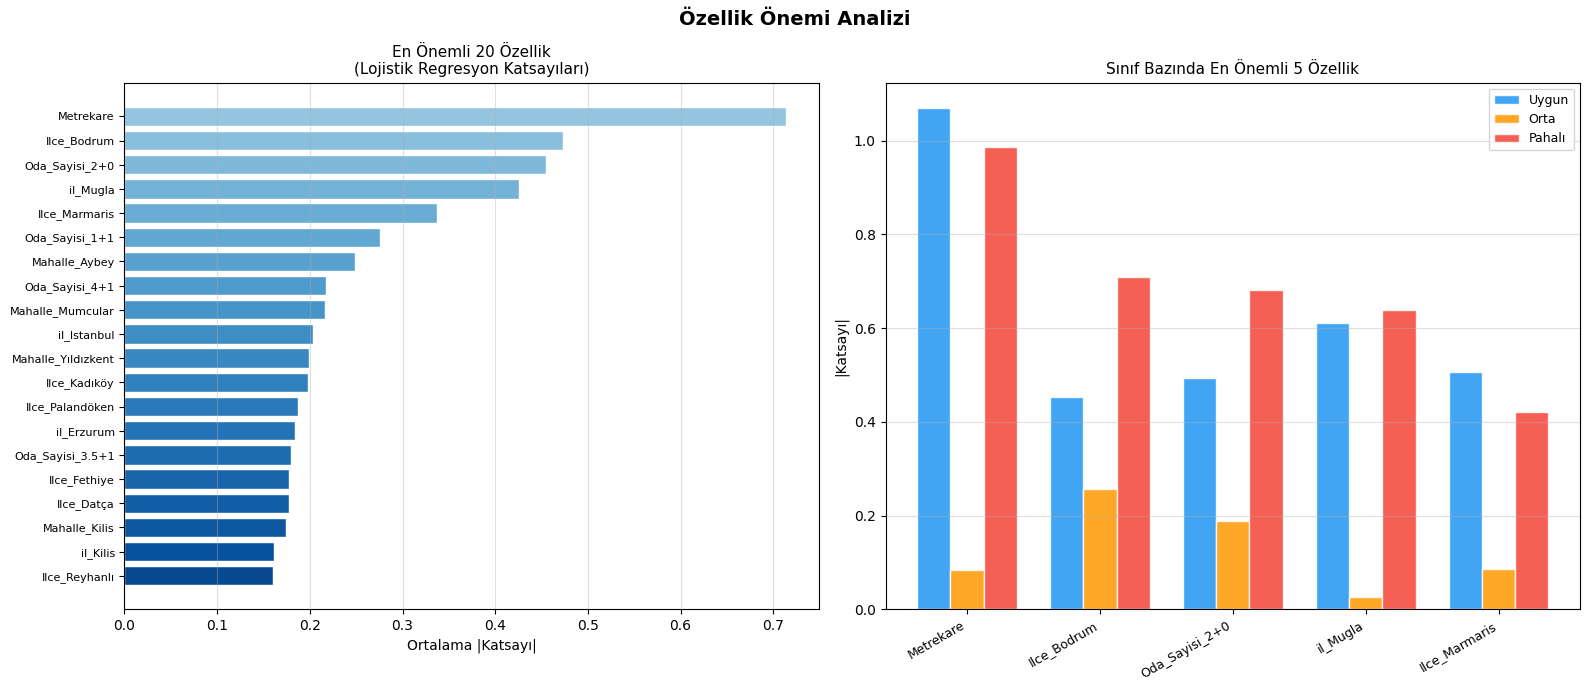

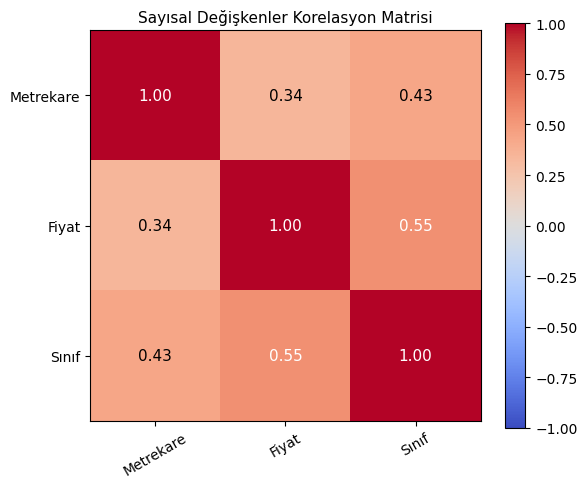


── En Önemli 5 Özellik ──────────────────────────────────
  1. Metrekare                           önem: 0.7135
  2. Ilce_Bodrum                         önem: 0.4727
  3. Oda_Sayisi_2+0                      önem: 0.4545
  4. il_Mugla                            önem: 0.4253
  5. Ilce_Marmaris                       önem: 0.3375

✓ Hücre 13 tamamlandı.


In [29]:
# Özellik Önemi

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("Özellik Önemi Analizi başlıyor …")

# 1. Lojistik Regresyon katsayıları
coef_abs = np.abs(logreg_baseline.coef_)   # (3, n_features)
mean_imp  = coef_abs.mean(axis=0)          # Her özelliğin ortalama etkisi

# En önemli 20 özellik
top_n  = 20
top_idx = np.argsort(mean_imp)[-top_n:][::-1]
top_features = [feature_names[i] for i in top_idx]
top_values   = mean_imp[top_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Özellik Önemi Analizi", fontsize=14, fontweight="bold")

ax1 = axes[0]
colors_imp = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))[::-1]
bars = ax1.barh(range(top_n), top_values[::-1],
                color=colors_imp, edgecolor="white")
ax1.set_yticks(range(top_n))
ax1.set_yticklabels([f[:30] for f in top_features[::-1]], fontsize=8)
ax1.set_xlabel("Ortalama |Katsayı|", fontsize=10)
ax1.set_title("En Önemli 20 Özellik\n(Lojistik Regresyon Katsayıları)", fontsize=11)
ax1.grid(axis="x", alpha=.4)

# 2. Sınıf bazında özellik önemi
ax2 = axes[1]
sinif_renkleri = ["#2196F3", "#FF9800", "#F44336"]
top5_idx = np.argsort(mean_imp)[-5:][::-1]

x_pos  = np.arange(5)
width  = 0.25
for i, (sinif, renk) in enumerate(zip(CLASS_NAMES, sinif_renkleri)):
    vals = coef_abs[i][top5_idx]
    ax2.bar(x_pos + i*width, vals, width, label=sinif,
            color=renk, edgecolor="white", alpha=0.85)

ax2.set_xticks(x_pos + width)
ax2.set_xticklabels([feature_names[i][:20] for i in top5_idx],
                    rotation=30, ha="right", fontsize=9)
ax2.set_ylabel("|Katsayı|", fontsize=10)
ax2.set_title("Sınıf Bazında En Önemli 5 Özellik", fontsize=11)
ax2.legend(fontsize=9); ax2.grid(axis="y", alpha=.4)

plt.tight_layout()
plt.savefig("ozellik_onemi.png", dpi=150, bbox_inches="tight"); plt.show()

# 3. Sayısal özellikler korelasyon
fig2, ax3 = plt.subplots(figsize=(6, 5))
num_df = df_raw[["Metrekare", PRICE_COL, "label"]].copy()
num_df["label"] = num_df["label"].astype(float)
corr = num_df.corr()
im = ax3.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax3)
ax3.set_xticks(range(len(corr))); ax3.set_yticks(range(len(corr)))
ax3.set_xticklabels(["Metrekare","Fiyat","Sınıf"], rotation=30)
ax3.set_yticklabels(["Metrekare","Fiyat","Sınıf"])
for i in range(len(corr)):
    for j in range(len(corr)):
        ax3.text(j, i, f"{corr.iloc[i,j]:.2f}",
                 ha="center", va="center", fontsize=11,
                 color="white" if abs(corr.iloc[i,j]) > 0.5 else "black")
ax3.set_title("Sayısal Değişkenler Korelasyon Matrisi", fontsize=11)
plt.tight_layout()
plt.savefig("korelasyon.png", dpi=150, bbox_inches="tight"); plt.show()

print("\n── En Önemli 5 Özellik ──────────────────────────────────")
for i, idx in enumerate(top5_idx):
    print(f"  {i+1}. {feature_names[idx]:<35} önem: {mean_imp[idx]:.4f}")
print("\n✓ Hücre 13 tamamlandı.")

In [30]:
# Bütçe Uygunluk ve Filtreleme Sistemi

import numpy as np
import pandas as pd

print("=" * 60)
print("BÜTÇE UYGUNLUK VE FİLTRELEME SİSTEMİ")
print("=" * 60)

def butce_analizi(il, ilce, metrekare, butce_tl, oda_sayisi=None,
                  satici_tip=None, tolerans_pct=20):
    """
    Kullanıcının girdiği özelliklere göre:
      1. CustomMLP ile fiyat sınıfı tahmin eder
      2. Bütçe uygunluğunu değerlendirir
      3. Veri setinden benzer uygun evleri listeler

    Parametreler:
      il           : string  (örn. "İstanbul")
      ilce         : string  (örn. "Kadıköy")
      metrekare    : int/float
      butce_tl     : int/float  (TL cinsinden)
      oda_sayisi   : string veya None  (örn. "3+1")
      satici_tip   : string veya None
      tolerans_pct : int  (metrekare tolerans yüzdesi, varsayılan ±%20)
    """

    print(f"\n{'─'*55}")
    print(f"  İl / İlçe    : {il} / {ilce}")
    print(f"  Metrekare    : {metrekare} m²")
    if oda_sayisi: print(f"  Oda Sayısı   : {oda_sayisi}")
    print(f"  Bütçe        : {butce_tl:,.0f} TL")
    print(f"{'─'*55}")

    # Adım 1: Örnek vektörü oluştur
    ornek = df_raw[
        (df_raw["il"].str.lower() == il.lower()) &
        (df_raw["Ilce"].str.lower() == ilce.lower())
    ]

    if len(ornek) == 0:
        print(f"  ⚠ '{il}/{ilce}' veri setinde bulunamadı.")
        print(f"    Mevcut iller: {sorted(df_raw['il'].unique())[:10]} …")
        return

    # En yakın metrekareli evi şablon olarak al
    ornek = ornek.copy()
    ornek["m2_fark"] = (ornek["Metrekare"] - metrekare).abs()
    sablon = ornek.sort_values("m2_fark").iloc[0].copy()

    sablon["Metrekare"] = metrekare
    if oda_sayisi:  sablon["Oda_Sayisi"] = oda_sayisi
    if satici_tip:  sablon["satici_tip"]  = satici_tip

    # Adım 2: One-Hot encode et ve ölçekle
    sablon_df = pd.DataFrame([sablon])

    # Tarih ve fiyat sütunlarını düşür
    for col in [PRICE_COL, "label", "Tarih", "m2_fark"]:
        if col in sablon_df.columns:
            sablon_df = sablon_df.drop(columns=[col])

    # One-Hot Encoding
    cat_cols_s = [c for c in sablon_df.columns if sablon_df[c].dtype == "object"]
    sablon_enc = pd.get_dummies(sablon_df, columns=cat_cols_s, drop_first=False)

    # Eksik sütunları 0 ile doldur, fazla sütunları çıkar
    for col in feature_names:
        if col not in sablon_enc.columns:
            sablon_enc[col] = 0
    sablon_enc = sablon_enc[feature_names]

    X_input = imputer.transform(sablon_enc.values.astype(np.float64))
    X_input = scaler.transform(X_input)

    # Adım 3: Model tahmini
    proba      = custom_mlp.predict_proba(X_input)[0]
    tahmin_idx = int(np.argmax(proba))
    tahmin_ad  = CLASS_NAMES[tahmin_idx]

    print(f"\n  📊 MODEL TAHMİNİ (CustomMLP):")
    for i, (ad, p) in enumerate(zip(CLASS_NAMES, proba)):
        bar = "█" * int(p * 20)
        isaretli = " ◄" if i == tahmin_idx else ""
        print(f"     {ad:<8}: {bar:<20} {p:.1%}{isaretli}")

    print(f"\n  Tahmin Edilen Sınıf : {tahmin_ad}")
    print(f"  Fiyat Aralığı       : {CLASS_RANGES[tahmin_idx]}")

    # Adım 4: Bütçe değerlendirmesi
    print(f"\n  💰 BÜTÇE DEĞERLENDİRMESİ:")
    if butce_tl < q33:
        butce_sinif = 0
    elif butce_tl < q66:
        butce_sinif = 1
    else:
        butce_sinif = 2

    if butce_sinif >= tahmin_idx:
        print(f"  ✅ Bütçeniz ({butce_tl:,.0f} TL) bu ev için YETERLİ.")
        print(f"     Bu ev '{tahmin_ad}' sınıfında, bütçeniz '{CLASS_NAMES[butce_sinif]}' sınıfında.")
    else:
        fark = q33 if tahmin_idx == 0 else (q66 if tahmin_idx == 1 else df_raw[PRICE_COL].max())
        print(f"  ❌ Bütçeniz ({butce_tl:,.0f} TL) bu ev için YETERSİZ.")
        print(f"     Bu sınıf için minimum bütçe: {CLASS_RANGES[tahmin_idx]}")

    # Adım 5: Benzer uygun evleri listele
    print(f"\n  🏠 {il}/{ilce} BÖLGESİNDE BENZER {tahmin_ad.upper()} EVLER:")

    tol = metrekare * tolerans_pct / 100
    filtre = (
        (df_raw["il"].str.lower()   == il.lower()) &
        (df_raw["Ilce"].str.lower() == ilce.lower()) &
        (df_raw["label"]            == tahmin_idx) &
        (df_raw["Metrekare"]        >= metrekare - tol) &
        (df_raw["Metrekare"]        <= metrekare + tol)
    )
    benzer = df_raw[filtre].copy()

    if len(benzer) == 0:
        # İlçe bulunamazsa ile genişlet
        filtre2 = (
            (df_raw["il"].str.lower() == il.lower()) &
            (df_raw["label"]          == tahmin_idx) &
            (df_raw["Metrekare"]      >= metrekare - tol) &
            (df_raw["Metrekare"]      <= metrekare + tol)
        )
        benzer = df_raw[filtre2].copy()
        print(f"  (İlçede bulunamadı, {il} genelinde aranıyor …)")

    if len(benzer) == 0:
        print("  Veri setinde eşleşen ev bulunamadı.")
    else:
        benzer = benzer.sort_values(PRICE_COL).head(5)
        goster = ["Mahalle","Metrekare","Oda_Sayisi","satici_tip", PRICE_COL]
        goster = [c for c in goster if c in benzer.columns]
        tablo  = benzer[goster].copy()
        tablo[PRICE_COL] = tablo[PRICE_COL].apply(lambda x: f"{x:,.0f} TL")
        tablo.columns = [c if c != PRICE_COL else "Fiyat" for c in tablo.columns]
        print(tablo.to_string(index=False))
        print(f"\n  Toplam {len(benzer)} eşleşen ev bulundu (ilk 5 gösteriliyor).")

    print(f"{'─'*55}")

BÜTÇE UYGUNLUK VE FİLTRELEME SİSTEMİ


In [31]:
# HAZIR SUNUM SENARYOLARI

print("\n" + "=" * 60)
print("SENARYO 1 — Orta Bütçeli Alıcı")
print("=" * 60)
butce_analizi(
    il          = "İstanbul",
    ilce        = "Kadıköy",
    metrekare   = 100,
    butce_tl    = 3_200_000,
    oda_sayisi  = "3+1"
)

print("\n" + "=" * 60)
print("SENARYO 2 — Düşük Bütçeli İlk Ev Alıcısı")
print("=" * 60)
butce_analizi(
    il          = "Ankara",
    ilce        = "Çankaya",
    metrekare   = 75,
    butce_tl    = 2_000_000,
    oda_sayisi  = "2+1"
)

print("\n" + "=" * 60)
print("SENARYO 3 — Yüksek Bütçeli Yatırımcı")
print("=" * 60)
butce_analizi(
    il          = "İzmir",
    ilce        = "Konak",
    metrekare   = 150,
    butce_tl    = 5_000_000,
    oda_sayisi  = "4+1"
)

print("\n✓ Hücre 14 tamamlandı.")
print("\n" + "=" * 60)
print("TÜM HÜCRELER TAMAMLANDI")
print("Kaydedilen dosyalar:")
for f in ["overfitting_test.png", "ab_test_sonuclari_v3.png",
          "relu_vs_sigmoid.png",  "derinlik_karsilastirma.png",
          "ozet_grafik.png",      "eda_analiz.png",
          "tarih_analiz.png",     "ozellik_onemi.png",
          "korelasyon.png"]:
    print(f"  ✓ {f}")
print("=" * 60)


SENARYO 1 — Orta Bütçeli Alıcı

───────────────────────────────────────────────────────
  İl / İlçe    : İstanbul / Kadıköy
  Metrekare    : 100 m²
  Oda Sayısı   : 3+1
  Bütçe        : 3,200,000 TL
───────────────────────────────────────────────────────
  ⚠ 'İstanbul/Kadıköy' veri setinde bulunamadı.
    Mevcut iller: ['Afyonkarahisar', 'Ardahan', 'Artvin', 'Aydin', 'Bayburt', 'Bilecik', 'Bingol', 'Bursa', 'Canakkale', 'Diyarbakir'] …

SENARYO 2 — Düşük Bütçeli İlk Ev Alıcısı

───────────────────────────────────────────────────────
  İl / İlçe    : Ankara / Çankaya
  Metrekare    : 75 m²
  Oda Sayısı   : 2+1
  Bütçe        : 2,000,000 TL
───────────────────────────────────────────────────────
  ⚠ 'Ankara/Çankaya' veri setinde bulunamadı.
    Mevcut iller: ['Afyonkarahisar', 'Ardahan', 'Artvin', 'Aydin', 'Bayburt', 'Bilecik', 'Bingol', 'Bursa', 'Canakkale', 'Diyarbakir'] …

SENARYO 3 — Yüksek Bütçeli Yatırımcı

───────────────────────────────────────────────────────
  İl / İlçe    : İ